# Supplementary Experiments

## Experiment 1 – Ambiguous Cases
Goal: Show that **high temperature reveals latent uncertainty** on boundary samples where
low-T decoding prematurely converges to a single verdict.

Key metrics: **Verdict Entropy**, **Flip Rate**, **Disagreement Lift**, **AGR / CON / ERR**.

## Experiment 2 – Ensemble Judging
Goal: Show that a **high-T majority-vote ensemble** (10 repeats → majority) can recover
agreement and reduce overconfidence relative to single-pass low-T decoding.

Key metrics: **Final AGR**, **Vote Entropy**, **CON**, **ERR** for each pipeline.

---
**Data**: `../output/combined_judge_dataset_qwen_gemma.csv`  
360 k rows · 500 questions · 2 models · 6 temps (0.01 – 3.0) · 10 repeats  
Judge types: pairwise / single_answer / reference_guided · Prompt variants: baseline / cot

In [29]:
from __future__ import annotations
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

try:
    from IPython.display import display
except ImportError:
    display = print  # fallback when running as plain script

FIGURE_DIR = Path('../output/supplementary_figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print('Imports OK')
print('Figure output dir:', FIGURE_DIR.resolve())

Imports OK
Figure output dir: /home/snt/projects_lujun/LLMJudgeTempCausal/output/supplementary_figures


In [30]:
def resolve_path(candidates):
    for c in candidates:
        p = Path(c)
        if p.exists():
            return p.resolve()
    raise FileNotFoundError('None found: ' + str(candidates))

DATA_PATH = resolve_path([
    'output/combined_judge_dataset_qwen_gemma.csv',
    '../output/combined_judge_dataset_qwen_gemma.csv',
])

df_raw = pd.read_csv(DATA_PATH)

temps     = sorted(df_raw['temperature'].unique())
models    = df_raw['judge_model'].unique().tolist()
jtypes    = df_raw['judge_type'].unique().tolist()
pvariants = df_raw['prompt_variant'].unique().tolist()

print(f'Loaded {len(df_raw):,} rows  |  path: {DATA_PATH.name}')
print(f'Temperatures    : {temps}')
print(f'Judge models    : {models}')
print(f'Judge types     : {jtypes}')
print(f'Prompt variants : {pvariants}')
print(f'Questions       : {df_raw["question_id"].nunique()}')
print(f'Repeats         : {sorted(df_raw["repeat_id"].unique())}')
print(f'Format errors   : {df_raw["format_error"].sum():,} ({df_raw["format_error"].mean():.2%})')

Loaded 360,000 rows  |  path: combined_judge_dataset_qwen_gemma.csv
Temperatures    : [np.float64(0.01), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(3.0)]
Judge models    : ['Qwen/Qwen3-Next-80B-A3B-Instruct-FP8', 'google/gemma-3-27b-it']
Judge types     : ['pairwise', 'single_answer', 'reference_guided']
Prompt variants : ['baseline', 'cot']
Questions       : 500
Repeats         : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Format errors   : 15,908 (4.42%)


In [31]:
# ─── Helper functions ────────────────────────────────────────────────────────

VALID_VERDICTS = {'A', 'B', 'C'}

def verdict_entropy(series) -> float:
    """Shannon entropy (bits) of a verdict distribution {A, B, C}."""
    valid = series.dropna()
    valid = valid[valid.isin(VALID_VERDICTS)]
    if len(valid) == 0:
        return np.nan
    probs = valid.value_counts(normalize=True)
    return float(-(probs * np.log2(probs + 1e-12)).sum())


def majority_verdict(series):
    """Most common valid verdict; np.nan if no valid verdicts."""
    valid = series.dropna()
    valid = valid[valid.isin(VALID_VERDICTS)]
    if len(valid) == 0:
        return np.nan
    return valid.value_counts().idxmax()


def consistency_score(series) -> float:
    """Fraction of repeats matching the majority verdict (internal consistency)."""
    valid = series.dropna()
    valid = valid[valid.isin(VALID_VERDICTS)]
    if len(valid) < 2:
        return np.nan
    maj = valid.value_counts().idxmax()
    return float((valid == maj).mean())


GOLD_MAP = {'model_a': 'A', 'model_b': 'B', 'tie': 'C'}

def ensemble_agreement(final_verdict, gold_winner) -> float:
    """1 if final_verdict matches gold_winner (mapped to A/B/C), else 0."""
    gold_abc = GOLD_MAP.get(str(gold_winner), np.nan)
    if pd.isna(final_verdict) or pd.isna(gold_abc):
        return np.nan
    return 1.0 if final_verdict == gold_abc else 0.0


print('Helper functions defined: verdict_entropy, majority_verdict, consistency_score, ensemble_agreement')

Helper functions defined: verdict_entropy, majority_verdict, consistency_score, ensemble_agreement


---
## Experiment 1 – Ambiguous Cases

### 1.1 Sample Classification Strategy

For each `(question_id, judge_model, prompt_variant)` tuple, we compute the **verdict entropy**
at T = 0.01 across 10 repeats.

- **Non-Ambiguous (clear)**: entropy = 0 at T = 0.01 **and** stays low at high T.
- **Ambiguous**: entropy = 0 at T = 0.01 (low-T unanimous) **but** entropy > 0 at high T (≥ 1.5).
  These are samples where low-T prematurely collapses to one verdict.

### 1.2 Metrics
| Metric | Definition |
|---|---|
| Verdict Entropy | Shannon entropy (bits) of verdict distribution across 10 repeats |
| Flip Rate | Fraction of samples where majority verdict at T differs from majority at T = 0.01 |
| Disagreement Lift | mean entropy(high-T) − mean entropy(low-T = 0.01) |

### 1.3 Temperature Groups
| Group | Temperatures |
|---|---|
| Low | 0.01 |
| Mid | 0.5, 1.0 |
| High | 1.5, 2.0, 3.0 |

In [32]:
# ─── Exp 1 setup: filter pairwise, define temperature groups ─────────────────

LOW_T  = [0.01]
MID_T  = [0.5, 1.0]
HIGH_T = [1.5, 2.0, 3.0]
ALL_T  = LOW_T + MID_T + HIGH_T

TEMP_GROUP = {}
for t in LOW_T:  TEMP_GROUP[t] = 'Low (0.01)'
for t in MID_T:  TEMP_GROUP[t] = f'Mid ({t})'
for t in HIGH_T: TEMP_GROUP[t] = f'High ({t})'

# Use pairwise judgments only for Exp 1
pw = df_raw[df_raw['judge_type'] == 'pairwise'].copy()
# Drop format-error rows entirely (before any analysis)
pw = pw[~pw['format_error'].astype(bool)].reset_index(drop=True)
pw['verdict'] = pw['pairwise_winner'].copy()
pw['temp_group'] = pw['temperature'].map(TEMP_GROUP)

print(f'Pairwise rows   : {len(pw):,}')
print(f'Unique questions: {pw["question_id"].nunique()}')
print(f'Format error %  : {pw["format_error"].mean():.3%}')

Pairwise rows   : 120,000
Unique questions: 500
Format error %  : 5.314%


In [33]:
# ─── Compute per-question verdict entropy at each temperature ─────────────────

GROUP_COLS = ['question_id', 'judge_model', 'prompt_variant', 'temperature']

ent = (
    pw.groupby(GROUP_COLS)['verdict']
    .agg(
        entropy   = verdict_entropy,
        majority  = majority_verdict,
        n_total   = 'count',
        n_valid   = lambda x: x.dropna().isin(VALID_VERDICTS).sum(),
        error_rate = lambda x: (~x.isin(VALID_VERDICTS) | x.isna()).mean(),
    )
    .reset_index()
)
ent['temp_group'] = ent['temperature'].map(TEMP_GROUP)

print(f'Entropy table shape: {ent.shape}')
print('\nMean entropy by temperature:')
display(
    ent.groupby('temperature')
    .agg(mean_entropy=('entropy', 'mean'), std_entropy=('entropy', 'std'))
    .round(4)
)

Entropy table shape: (12000, 10)

Mean entropy by temperature:


,mean_entropy,std_entropy
temperature,,
0.0100,0.0436,0.1927
0.5000,0.0721,0.2465
1.0000,0.1046,0.2897
1.5000,0.1469,0.3344
2.0000,0.2087,0.3890
3.0000,0.4009,0.4990


In [34]:
# ─── Define Ambiguous vs Non-Ambiguous samples ────────────────────────────────
#
# Ambiguous  := entropy < LOW_ENT_THRESH at T=0.01 (near-unanimous)  AND  mean entropy > HIGH_ENT_THRESH at High-T
#               These are "false stable" samples: low-T converges but high-T diverges.
# Non-Ambig  := entropy < LOW_ENT_THRESH at T=0.01  AND  mean entropy <= HIGH_ENT_THRESH at High-T (genuinely easy).
# Thresholds use 0.01 to handle floating-point near-zero entropy (log2 with +1e-12 offset).

META_COLS = ['question_id', 'judge_model', 'prompt_variant']

# Stats at T=0.01
low_info = (
    ent[ent['temperature'] == 0.01]
    [META_COLS + ['entropy', 'majority']]
    .rename(columns={'entropy': 'ent_low', 'majority': 'maj_low'})
)

# Aggregate entropy across High-T (mean and max)
high_info = (
    ent[ent['temperature'].isin(HIGH_T)]
    .groupby(META_COLS)
    .agg(ent_high_mean=('entropy', 'mean'), ent_high_max=('entropy', 'max'))
    .reset_index()
)

# Majority verdict pooled over all high-T repeats
high_maj = (
    pw[pw['temperature'].isin(HIGH_T)]
    .groupby(META_COLS)['verdict']
    .apply(majority_verdict)
    .reset_index()
    .rename(columns={'verdict': 'maj_high'})
)

sample_df = (
    low_info
    .merge(high_info, on=META_COLS)
    .merge(high_maj,  on=META_COLS)
)

# Core labels
LOW_ENT_THRESH  = 0.01   # ~ epsilon for floating-point near-zero entropy (log2 + 1e-12 offset)
HIGH_ENT_THRESH = 0.50   # require meaningful divergence at high-T (mean entropy > 0.5 bits ≈ ≥11% minority votes)
sample_df['ambiguous'] = (sample_df['ent_low'] < LOW_ENT_THRESH) & (sample_df['ent_high_mean'] > HIGH_ENT_THRESH)
sample_df['verdict_flip']    = (
    (sample_df['maj_low'] != sample_df['maj_high'])
    & sample_df['maj_low'].notna()
    & sample_df['maj_high'].notna()
)
sample_df['disagreement_lift'] = sample_df['ent_high_mean'] - sample_df['ent_low']

n_all  = len(sample_df)
n_amb  = int(sample_df['ambiguous'].sum())
n_flip = int(sample_df['verdict_flip'].sum())

print(f'Total (question × model × prompt) : {n_all:,}')
print(f'Ambiguous (low-T unanimous, high-T diverges) : {n_amb:,}  ({n_amb/n_all:.1%})')
print(f'Verdict flip (low vs high majority differs)  : {n_flip:,}  ({n_flip/n_all:.1%})')

print('\nAmbiguous rate by model and prompt variant:')
display(
    sample_df.groupby(['judge_model', 'prompt_variant'])
    ['ambiguous'].agg(n_ambiguous='sum', rate='mean', total='count')
    .round(4)
)


Total (question × model × prompt) : 2,000
Ambiguous (low-T unanimous, high-T diverges) : 847  (42.4%)
Verdict flip (low vs high majority differs)  : 61  (3.0%)

Ambiguous rate by model and prompt variant:


n_ambiguous   rate  total
judge_model                          prompt_variant                           
Qwen/Qwen3-Next-80B-A3B-Instruct-FP8 baseline                234 0.4680    500
                                     cot                     296 0.5920    500
google/gemma-3-27b-it                baseline                 90 0.1800    500
                                     cot                     227 0.4540    500

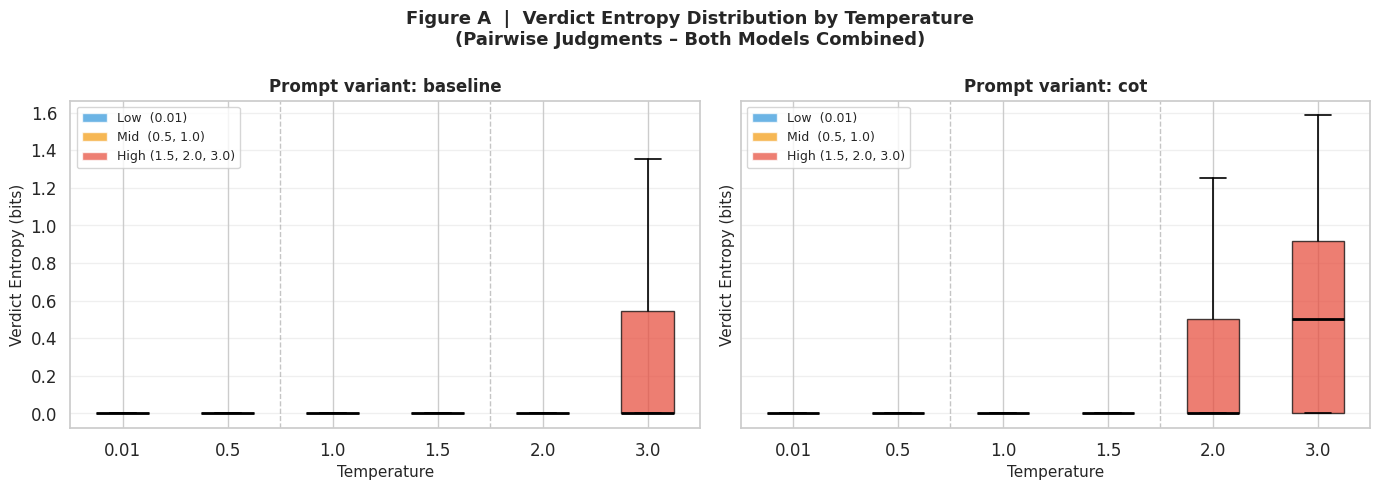

Saved: exp1_entropy_boxplot.png


In [35]:
# ─── Figure A: Verdict Entropy Distribution Boxplot by Temperature ─────────────

T_ORDER  = [0.01, 0.5, 1.0, 1.5, 2.0, 3.0]
T_LABELS = ['0.01', '0.5', '1.0', '1.5', '2.0', '3.0']

COL_LOW  = '#3498DB'
COL_MID  = '#F39C12'
COL_HIGH = '#E74C3C'
BOX_COLORS = [COL_LOW, COL_MID, COL_MID, COL_HIGH, COL_HIGH, COL_HIGH]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, pv in zip(axes, ['baseline', 'cot']):
    sub = ent[ent['prompt_variant'] == pv]
    bp_data = [sub[sub['temperature'] == t]['entropy'].dropna().values for t in T_ORDER]
    bp = ax.boxplot(
        bp_data,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markersize=2, alpha=0.25, markeredgewidth=0),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
    )
    for patch, color in zip(bp['boxes'], BOX_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.72)

    ax.set_xticklabels(T_LABELS)
    ax.set_xlabel('Temperature', fontsize=11)
    ax.set_ylabel('Verdict Entropy (bits)', fontsize=11)
    ax.set_title(f'Prompt variant: {pv}', fontsize=12, fontweight='bold')
    ax.axvline(x=2.5, color='gray', linestyle='--', alpha=0.45, linewidth=1)  # Low→Mid boundary
    ax.axvline(x=4.5, color='gray', linestyle='--', alpha=0.45, linewidth=1)  # Mid→High boundary
    ax.grid(True, axis='y', alpha=0.3)

    legend_handles = [
        Patch(facecolor=COL_LOW,  alpha=0.72, label='Low  (0.01)'),
        Patch(facecolor=COL_MID,  alpha=0.72, label='Mid  (0.5, 1.0)'),
        Patch(facecolor=COL_HIGH, alpha=0.72, label='High (1.5, 2.0, 3.0)'),
    ]
    ax.legend(handles=legend_handles, fontsize=9, loc='upper left')

fig.suptitle(
    'Figure A  |  Verdict Entropy Distribution by Temperature\n'
    '(Pairwise Judgments – Both Models Combined)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'exp1_entropy_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp1_entropy_boxplot.png')

In [36]:
# ─── Flip Rate vs T=0.01 baseline ─────────────────────────────────────────────
#
# Flip = majority verdict at temperature T differs from majority at T=0.01.

maj_wide = (
    ent.pivot_table(
        index=META_COLS,
        columns='temperature',
        values='majority',
        aggfunc='first',
    )
    .reset_index()
    .merge(sample_df[META_COLS + ['ambiguous']], on=META_COLS, how='left')
)

FLIP_TEMPS = [0.5, 1.0, 1.5, 2.0, 3.0]
flip_col_map = {}
for t in FLIP_TEMPS:
    col = f'flip_{t}'
    valid = maj_wide[0.01].notna() & maj_wide[t].notna()
    maj_wide[col] = (maj_wide[0.01] != maj_wide[t]) & valid
    flip_col_map[t] = col

# Aggregate flip rates by subset (All / Ambiguous / Non-Ambiguous)
records = []
for is_amb, label in [(None, 'All'), (True, 'Ambiguous'), (False, 'Non-Ambiguous')]:
    sub = maj_wide if is_amb is None else maj_wide[maj_wide['ambiguous'] == is_amb]
    for t, col in flip_col_map.items():
        records.append({'Subset': label, 'Temperature': t, 'Flip Rate': float(sub[col].mean())})

flip_df = pd.DataFrame(records)

print('=== Flip Rate vs T=0.01 Baseline ===')
display(
    flip_df.pivot(index='Subset', columns='Temperature', values='Flip Rate').round(4)
)

=== Flip Rate vs T=0.01 Baseline ===


Temperature,0.5000,1.0000,1.5000,2.0000,3.0000
Subset,,,,,
All,0.0210,0.0255,0.0275,0.0405,0.0805
Ambiguous,0.0130,0.0189,0.0272,0.0437,0.1287
Non-Ambiguous,0.0269,0.0304,0.0278,0.0382,0.0451


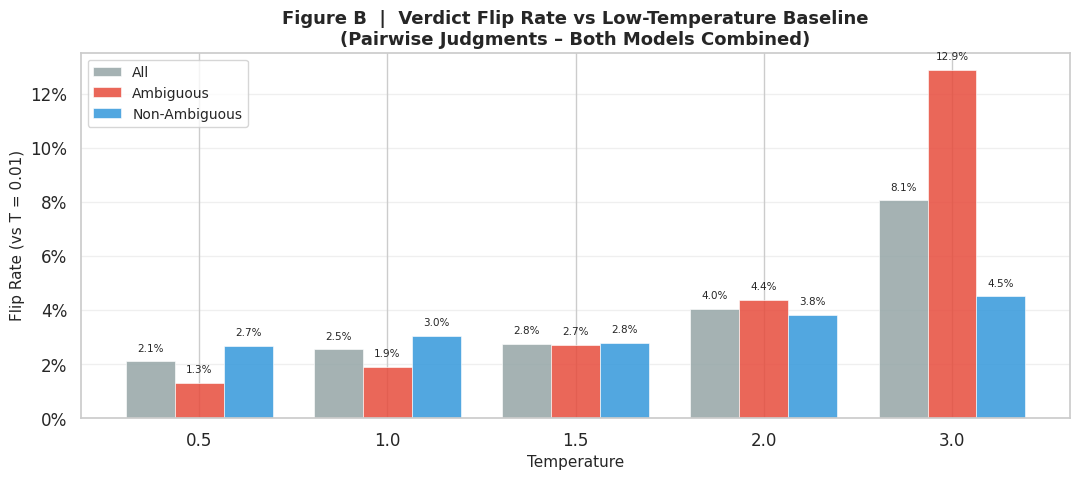

Saved: exp1_flip_rate_bar.png


In [37]:
# ─── Figure B: Verdict Flip Rate Bar Chart ─────────────────────────────────────

temps_plot = sorted(flip_col_map.keys())
x = np.arange(len(temps_plot))
width = 0.26

SUBSET_STYLE = {
    'All':           {'color': '#95A5A6', 'offset': -width},
    'Ambiguous':     {'color': '#E74C3C', 'offset':  0.0},
    'Non-Ambiguous': {'color': '#3498DB', 'offset':  width},
}

fig, ax = plt.subplots(figsize=(11, 5))

for subset, style in SUBSET_STYLE.items():
    vals = [
        float(flip_df[(flip_df['Subset'] == subset) & (flip_df['Temperature'] == t)]['Flip Rate'].values[0])
        for t in temps_plot
    ]
    bars = ax.bar(
        x + style['offset'], vals, width,
        label=subset, color=style['color'],
        alpha=0.85, edgecolor='white', linewidth=0.5
    )
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.1%}', ha='center', va='bottom', fontsize=7.5
        )

ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in temps_plot])
ax.set_xlabel('Temperature', fontsize=11)
ax.set_ylabel('Flip Rate (vs T = 0.01)', fontsize=11)
ax.set_title(
    'Figure B  |  Verdict Flip Rate vs Low-Temperature Baseline\n'
    '(Pairwise Judgments – Both Models Combined)',
    fontsize=13, fontweight='bold'
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, None)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'exp1_flip_rate_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp1_flip_rate_bar.png')

In [38]:
# ─── Disagreement Lift Table ───────────────────────────────────────────────────

print('=== Disagreement Lift (mean entropy increase Low-T → High-T) ===')
lift_tbl = (
    sample_df.groupby(['judge_model', 'prompt_variant', 'ambiguous'])
    .agg(
        mean_ent_low  = ('ent_low',       'mean'),
        mean_ent_high = ('ent_high_mean', 'mean'),
        mean_lift     = ('disagreement_lift', 'mean'),
        n             = ('disagreement_lift', 'count'),
    )
    .reset_index()
)
lift_tbl['ambiguous'] = lift_tbl['ambiguous'].map({True: 'Ambiguous', False: 'Non-Ambiguous'})
display(lift_tbl.round(4))

=== Disagreement Lift (mean entropy increase Low-T → High-T) ===


,judge_model,prompt_variant,ambiguous,mean_ent_low,mean_ent_high,mean_lift,n
0,Qwen/Qwen3-Next-80B-A3B-Instruct-FP8,baseline,Non-Ambiguous,0.0826,0.1030,0.0204,266
1,Qwen/Qwen3-Next-80B-A3B-Instruct-FP8,baseline,Ambiguous,-0.0000,0.4702,0.4702,234
2,Qwen/Qwen3-Next-80B-A3B-Instruct-FP8,cot,Non-Ambiguous,0.2450,0.2793,0.0311,195
3,Qwen/Qwen3-Next-80B-A3B-Instruct-FP8,cot,Ambiguous,-0.0000,0.4993,0.4993,296
4,google/gemma-3-27b-it,baseline,Non-Ambiguous,0.0092,0.0126,0.0034,410
5,google/gemma-3-27b-it,baseline,Ambiguous,-0.0000,0.4382,0.4382,90
6,google/gemma-3-27b-it,cot,Non-Ambiguous,0.0490,0.0584,0.0094,273
7,google/gemma-3-27b-it,cot,Ambiguous,-0.0000,0.4466,0.4466,227


In [39]:
# ─── AGR / CON / ERR Table: Ambiguous vs Non-Ambiguous by Temperature Group ───

# Tag ambiguous label onto original pairwise rows
pw_tagged = pw.merge(
    sample_df[META_COLS + ['ambiguous']],
    on=META_COLS,
    how='left',
)

def temp_group_label(t):
    if t in LOW_T:  return 'Low'
    if t in MID_T:  return 'Mid'
    return 'High'

pw_tagged['tgroup'] = pw_tagged['temperature'].map(temp_group_label)

rows = []
for (amb_val, tgrp), grp in pw_tagged.groupby(['ambiguous', 'tgroup']):
    agr = grp['agreement'].mean()
    err = grp['format_error'].astype(float).mean()
    con = (
        grp.groupby(['question_id', 'judge_model', 'prompt_variant', 'temperature'])['verdict']
        .apply(consistency_score)
        .mean()
    )
    rows.append({
        'Subset':     'Ambiguous' if amb_val else 'Non-Ambiguous',
        'Temp Group': tgrp,
        'AGR':        agr,
        'CON':        con,
        'ERR':        err,
        'N Rows':     len(grp),
    })

agr_table_raw = pd.DataFrame(rows).set_index(['Subset', 'Temp Group'])
DESIRED_ROWS = [
    ('Ambiguous',     'Low'),  ('Ambiguous',     'Mid'),  ('Ambiguous',     'High'),
    ('Non-Ambiguous', 'Low'),  ('Non-Ambiguous', 'Mid'),  ('Non-Ambiguous', 'High'),
]
valid_rows = [r for r in DESIRED_ROWS if r in agr_table_raw.index]
agr_table = agr_table_raw.loc[valid_rows]

print('=== AGR / CON / ERR  –  Ambiguous vs Non-Ambiguous Subsets ===')
display(agr_table.round(4))


=== AGR / CON / ERR  –  Ambiguous vs Non-Ambiguous Subsets ===


AGR    CON    ERR  N Rows
Subset        Temp Group                             
Ambiguous     Low        0.5070 1.0000 0.0329    8470
              Mid        0.5064 0.9686 0.0403   16940
              High       0.4946 0.8534 0.1081   25410
Non-Ambiguous Low        0.6351 0.9750 0.0194   11530
              Mid        0.6363 0.9725 0.0212   23060
              High       0.6326 0.9674 0.0565   34590

---
## Experiment 2 – Ensemble Judging

> **Scope**: This experiment runs **exclusively on the Ambiguous cases identified in Experiment 1** —
> questions where low-T decoding produces unanimous verdicts, yet high-T decoding reveals latent
> disagreement. This restriction makes the core claim directly testable:
> *"High temperature's value is not in the final output itself, but in broadening the judge's
> search space and surfacing uncertainty on hard cases."*

### 2.1 Pipelines

| Pipeline | Temperature | Repeats | Aggregation |
|---|---|---|---|
| **SP-Low** (single-pass) | 0.01 | 1 (repeat 0) | – |
| **SP-Mid** (single-pass) | 1.0  | 1 (repeat 0) | – |
| **Ens-Low** (ensemble)   | 0.01 | 10 | Majority vote |
| **Ens-High-1.5** (ensemble) | 1.5 | 10 | Majority vote |
| **Ens-High-2.0** (ensemble) | 2.0 | 10 | Majority vote |

Ens-Low is a strong ceiling baseline (multi-pass low-T).
Ens-High explores whether high-T diversity + majority vote recovers accuracy on ambiguous cases.

### 2.2 Metrics
| Metric | Definition |
|---|---|
| **Final AGR** | Fraction of questions where final (aggregated) verdict matches gold label |
| **Vote Entropy** | Mean Shannon entropy of 10 pre-vote verdicts |
| **CON** | Mean fraction of repeats matching majority verdict |
| **ERR** | Fraction of format errors across all repeats |

### 2.3 Contrast Design
Pipelines are run on **both** subsets for comparison:
- **Ambiguous** (main): falsely stable at low-T → high-T should help
- **Non-Ambiguous** (control): genuinely easy → high-T should NOT help (or even hurt)

If AGR gain from high-T ensemble is **larger for Ambiguous than Non-Ambiguous**, the causal
claim is supported.

In [ ]:
# ─── Exp 2 pipeline definitions ───────────────────────────────────────────────

PIPELINES = {
    'SP-Low\n(T=0.01,N=1)':    {'temps': [0.01], 'repeats': [0],            'agg': 'single'},
    'SP-Mid\n(T=1.0,N=1)':     {'temps': [1.0],  'repeats': [0],            'agg': 'single'},
    'Ens-Low\n(T=0.01,N=10)':  {'temps': [0.01], 'repeats': list(range(10)),'agg': 'majority_vote'},
    'Ens-High\n(T=1.5,N=10)':  {'temps': [1.5],  'repeats': list(range(10)),'agg': 'majority_vote'},
    'Ens-High\n(T=2.0,N=10)':  {'temps': [2.0],  'repeats': list(range(10)),'agg': 'majority_vote'},
    'Ens-High\n(T=3.0,N=10)':  {'temps': [3.0],  'repeats': list(range(10)),'agg': 'majority_vote'},
    'Ens-Mixed\n(Mix-T,N=15)': {'temps': [0.5, 1.0, 1.5, 2.0, 3.0], 'repeats': [0, 1, 2], 'agg': 'majority_vote'},
}
PIPELINE_COLORS = [
    '#3498DB',   # SP-Low
    '#F39C12',   # SP-Mid
    '#2ECC71',   # Ens-Low
    '#E74C3C',   # Ens-High 1.5
    '#C0392B',   # Ens-High 2.0
    '#8E44AD',   # Ens-High 3.0
    '#9B59B6',   # Ens-Mixed
]

AMB_IDS    = set(sample_df.loc[sample_df['ambiguous'], 'question_id'].unique())
NONAMB_IDS = set(df_raw['question_id'].unique()) - AMB_IDS

# Baseline prompt variant
pw_base = pw[pw['prompt_variant'] == 'baseline'].copy()
pw_base['gold_abc'] = pw_base['gold_winner'].map(GOLD_MAP)
pw_base_amb    = pw_base[pw_base['question_id'].isin(AMB_IDS)].copy()
pw_base_nonamb = pw_base[pw_base['question_id'].isin(NONAMB_IDS)].copy()

# CoT prompt variant
pw_cot = pw[pw['prompt_variant'] == 'cot'].copy()
pw_cot['gold_abc'] = pw_cot['gold_winner'].map(GOLD_MAP)
pw_cot_amb    = pw_cot[pw_cot['question_id'].isin(AMB_IDS)].copy()
pw_cot_nonamb = pw_cot[pw_cot['question_id'].isin(NONAMB_IDS)].copy()

print(f'Total pairwise rows          : {len(pw):,}')
print(f'Gold label coverage (base)   : {pw_base["gold_abc"].notna().mean():.1%}')
print()
print(f'Ambiguous question IDs       : {len(AMB_IDS):,}')
print(f'  baseline AMB rows          : {len(pw_base_amb):,}')
print(f'  cot      AMB rows          : {len(pw_cot_amb):,}')
print(f'Non-Ambiguous question IDs   : {len(NONAMB_IDS):,}')
print(f'  baseline NonAmb rows       : {len(pw_base_nonamb):,}')
print(f'  cot      NonAmb rows       : {len(pw_cot_nonamb):,}')


In [41]:
# ─── Function: compute per-question metrics for a pipeline ────────────────────

def compute_pipeline_metrics(sub_df, agg_mode):
    """
    sub_df   : filtered DataFrame for the pipeline (one or more temps/repeats)
    agg_mode : 'single' (use first row) or 'majority_vote' (aggregate 10 repeats)

    Returns a DataFrame with one row per (question_id, judge_model).
    """
    records = []

    for (qid, model), grp in sub_df.groupby(['question_id', 'judge_model']):
        verdicts_s = grp['verdict']
        gold       = grp['gold_abc'].iloc[0] if grp['gold_abc'].notna().any() else np.nan

        # Vote entropy and CON computed over available repeats
        v_ent = verdict_entropy(verdicts_s)
        con   = consistency_score(verdicts_s)
        err   = float(grp['format_error'].astype(float).mean())

        # Final verdict
        if agg_mode == 'single':
            final_v = grp['verdict'].iloc[0]  # repeat_id=0 guaranteed by filter
        else:
            final_v = majority_verdict(verdicts_s)

        # gold is already mapped to A/B/C, compare directly
        agr = (1.0 if final_v == gold else 0.0) if (pd.notna(final_v) and pd.notna(gold)) else np.nan

        records.append({
            'question_id':   qid,
            'judge_model':   model,
            'gold_abc':      gold,
            'final_verdict': final_v,
            'AGR':           agr,
            'CON':           con,
            'ERR':           err,
            'vote_entropy':  v_ent,
        })

    return pd.DataFrame(records)


print('compute_pipeline_metrics defined.')


compute_pipeline_metrics defined.


In [ ]:
# ─── Run all pipelines on Ambiguous Cases (Baseline + CoT) ──────────────────

pipe_results     = {}  # baseline, ambiguous
pipe_results_cot = {}  # cot,      ambiguous

for name, cfg in PIPELINES.items():
    pname = name.replace('\n', ' ')

    # Baseline
    sub = pw_base_amb[
        pw_base_amb['temperature'].isin(cfg['temps']) &
        pw_base_amb['repeat_id'].isin(cfg['repeats'])
    ]
    res = compute_pipeline_metrics(sub, cfg['agg'])
    pipe_results[name] = res

    # CoT
    sub_cot = pw_cot_amb[
        pw_cot_amb['temperature'].isin(cfg['temps']) &
        pw_cot_amb['repeat_id'].isin(cfg['repeats'])
    ]
    res_cot = compute_pipeline_metrics(sub_cot, cfg['agg'])
    pipe_results_cot[name] = res_cot

    print(f'{pname:<35} | Baseline: AGR={res["AGR"].mean():.4f}  CON={res["CON"].mean():.4f}  '
          f'Ent={res["vote_entropy"].mean():.4f}'
          f'  ||  CoT: AGR={res_cot["AGR"].mean():.4f}  CON={res_cot["CON"].mean():.4f}  '
          f'Ent={res_cot["vote_entropy"].mean():.4f}')


In [ ]:
# ─── Aggregate metrics comparison table (Ambiguous Cases, Baseline + CoT) ────

def build_metrics_tbl(pipe_res):
    records = []
    for name, res in pipe_res.items():
        records.append({
            'Pipeline':      name.replace('\n', ' '),
            'AGR (Final)':   res['AGR'].mean(),
            'CON':           res['CON'].mean(),
            'ERR':           res['ERR'].mean(),
            'Vote Entropy':  res['vote_entropy'].mean(),
            'N Questions':   res['question_id'].nunique(),
        })
    return pd.DataFrame(records).set_index('Pipeline')

metrics_tbl     = build_metrics_tbl(pipe_results)
metrics_tbl_cot = build_metrics_tbl(pipe_results_cot)

print('=== Pipeline Metrics – Baseline  [Ambiguous Cases Only] ===')
display(metrics_tbl.round(4))
print('\n=== Pipeline Metrics – CoT  [Ambiguous Cases Only] ===')
display(metrics_tbl_cot.round(4))


In [ ]:
# ─── Figure C: Pipeline Comparison Bar Chart (Baseline + CoT, Ambiguous Cases) ─

PIPELINE_NAMES = list(PIPELINES.keys())
PLOT_METRICS   = ['AGR (Final)', 'CON', 'ERR', 'Vote Entropy']
PLOT_YLABELS   = ['Agreement', 'Consistency', 'Error Rate', 'Entropy (bits)']
METRIC_TITLES  = [
    'Final Agreement (AGR)',
    'Internal Consistency (CON)',
    'Format Error Rate (ERR)',
    'Vote Entropy',
]

x = np.arange(len(PIPELINE_NAMES))
PIPE_LABELS = [n.replace('\n', '\n') for n in PIPELINE_NAMES]
VARIANT_TBLS = [('Baseline', metrics_tbl), ('CoT', metrics_tbl_cot)]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for row_idx, (variant_name, tbl) in enumerate(VARIANT_TBLS):
    for ax, metric, ylabel, title in zip(axes[row_idx], PLOT_METRICS, PLOT_YLABELS, METRIC_TITLES):
        pname_keys = [n.replace('\n', ' ') for n in PIPELINE_NAMES]
        vals = [tbl.loc[k, metric] for k in pname_keys]
        bars = ax.bar(x, vals, color=PIPELINE_COLORS, alpha=0.85, edgecolor='white', linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(PIPE_LABELS, fontsize=7.5)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(f'{title}\n[{variant_name}]', fontsize=10, fontweight='bold')
        ax.grid(True, axis='y', alpha=0.3)
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5
            )

fig.suptitle(
    'Figure C  |  Ensemble vs Single-Pass: Ambiguous Cases Only\n'
    'Top row: Baseline Prompt   Bottom row: CoT Prompt',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'exp2_pipeline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp2_pipeline_comparison.png')


In [ ]:
# ─── Run pipelines on Non-Ambiguous Cases (Baseline + CoT) ──────────────────

pipe_results_nonamb     = {}  # baseline, non-ambiguous
pipe_results_nonamb_cot = {}  # cot,      non-ambiguous

for name, cfg in PIPELINES.items():
    pname = name.replace('\n', ' ')

    sub = pw_base_nonamb[
        pw_base_nonamb['temperature'].isin(cfg['temps']) &
        pw_base_nonamb['repeat_id'].isin(cfg['repeats'])
    ]
    res = compute_pipeline_metrics(sub, cfg['agg'])
    pipe_results_nonamb[name] = res

    sub_cot = pw_cot_nonamb[
        pw_cot_nonamb['temperature'].isin(cfg['temps']) &
        pw_cot_nonamb['repeat_id'].isin(cfg['repeats'])
    ]
    res_cot = compute_pipeline_metrics(sub_cot, cfg['agg'])
    pipe_results_nonamb_cot[name] = res_cot

    print(f'{pname:<35} | Baseline: AGR={res["AGR"].mean():.4f}  ||  CoT: AGR={res_cot["AGR"].mean():.4f}')

# Build contrast tables for both variants
def build_contrast_tbl(pipe_amb, pipe_nonamb):
    records = []
    for name in PIPELINES:
        pname = name.replace('\n', ' ')
        res_amb    = pipe_amb[name]
        res_nonamb = pipe_nonamb[name]
        records.append({
            'Pipeline':             pname,
            'AGR – Ambiguous':      res_amb['AGR'].mean(),
            'AGR – Non-Ambiguous':  res_nonamb['AGR'].mean(),
            'AGR Δ (Amb−NonAmb)':   res_amb['AGR'].mean() - res_nonamb['AGR'].mean(),
            'VE – Ambiguous':       res_amb['vote_entropy'].mean(),
            'VE – Non-Ambiguous':   res_nonamb['vote_entropy'].mean(),
        })
    return pd.DataFrame(records).set_index('Pipeline')

contrast_tbl     = build_contrast_tbl(pipe_results,     pipe_results_nonamb)
contrast_tbl_cot = build_contrast_tbl(pipe_results_cot, pipe_results_nonamb_cot)

print('\n=== AGR / Vote Entropy: Ambiguous vs Non-Ambiguous  [Baseline] ===')
display(contrast_tbl.round(4))
print('\n=== AGR / Vote Entropy: Ambiguous vs Non-Ambiguous  [CoT] ===')
display(contrast_tbl_cot.round(4))


In [ ]:
# ─── Figure D: Ambiguous vs Non-Ambiguous AGR Contrast (Baseline + CoT) ────────

PNAME_ORDERED = [n.replace('\n', ' ') for n in PIPELINE_NAMES]

SUBSET_STYLE = {
    'Ambiguous':     {'ls': '-o',  'color': '#E74C3C', 'lw': 2.5, 'ms': 9},
    'Non-Ambiguous': {'ls': '--s', 'color': '#3498DB', 'lw': 2.0, 'ms': 7},
}

metric_map = [
    ('AGR – Ambiguous',  'AGR – Non-Ambiguous',  'AGR (Final)',         'Final Agreement (AGR)'),
    ('VE – Ambiguous',   'VE – Non-Ambiguous',   'Vote Entropy (bits)', 'Vote Entropy'),
]

VARIANT_CTBLS = [('Baseline', contrast_tbl), ('CoT', contrast_tbl_cot)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row_idx, (variant_name, ctbl) in enumerate(VARIANT_CTBLS):
    for ax, (col_amb, col_na, ylabel, title_str) in zip(axes[row_idx], metric_map):
        vals_amb = [float(ctbl.loc[p, col_amb]) for p in PNAME_ORDERED]
        vals_na  = [float(ctbl.loc[p, col_na])  for p in PNAME_ORDERED]

        for label, vals, style in [
            ('Ambiguous',     vals_amb, SUBSET_STYLE['Ambiguous']),
            ('Non-Ambiguous', vals_na,  SUBSET_STYLE['Non-Ambiguous']),
        ]:
            ax.plot(
                range(len(PNAME_ORDERED)), vals, style['ls'],
                label=label, color=style['color'],
                linewidth=style['lw'], markersize=style['ms']
            )

        ax.set_xticks(range(len(PNAME_ORDERED)))
        ax.set_xticklabels(PIPE_LABELS, fontsize=8)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f'{title_str}  [{variant_name}]', fontsize=11, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

fig.suptitle(
    'Figure D  |  Pipeline Effect: Ambiguous vs Non-Ambiguous Cases\n'
    'Top row: Baseline Prompt   Bottom row: CoT Prompt',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'exp2_ambiguous_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp2_ambiguous_comparison.png')


In [ ]:
# ─── CoT vs Baseline AGR Difference Summary ─────────────────────────────────

print('=== Diff CoT − Baseline  (AGR, Ambiguous Cases) ===')
diff_amb = (metrics_tbl_cot['AGR (Final)'] - metrics_tbl['AGR (Final)']).rename('AGR_diff_cot−baseline')
display(diff_amb.round(4).to_frame())

metrics_nonamb_tbl     = build_metrics_tbl(pipe_results_nonamb)
metrics_nonamb_cot_tbl = build_metrics_tbl(pipe_results_nonamb_cot)

print('\n=== Diff CoT − Baseline  (AGR, Non-Ambiguous Cases) ===')
diff_nonamb = (metrics_nonamb_cot_tbl['AGR (Final)'] - metrics_nonamb_tbl['AGR (Final)']).rename('AGR_diff_cot−baseline')
display(diff_nonamb.round(4).to_frame())


---
## Additional Validation Analyses

Three independent analyses to probe whether high temperature provides genuine benefits:

- **V1 – Entropy Calibration**: does Vote Entropy predict question difficulty (AGR decreases as entropy increases)?
- **V2 – Flip Correctness**: when verdict flips from low-T to high-T, is the new verdict more often correct?
- **V3 – Statistical Significance**: are AGR differences between pipelines statistically significant (paired t-test + bootstrap CI)?


Spearman rho(Vote Entropy, AGR) = -0.2207  (p = 0.0000)

=== V1: Mean AGR per Vote Entropy Quartile  [Ens-High T=2.0] ===


,AGR,vote_entropy
ent_q,,
"(-0.00100000000144, 0.361]",0.6042,0.0589
"(0.361, 1.428]",0.4759,0.6199


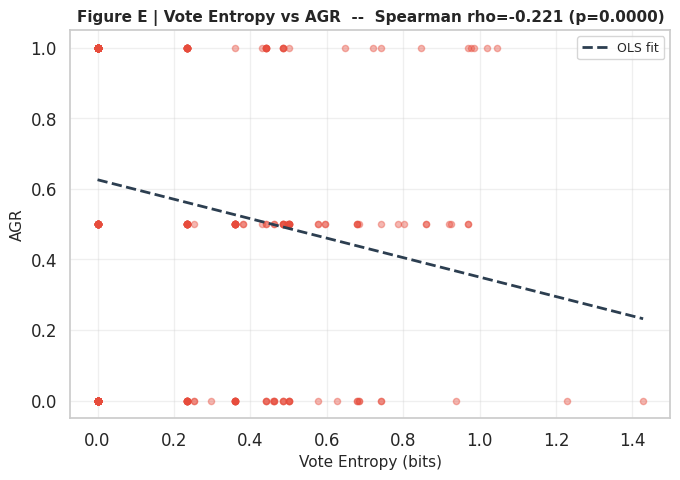

Saved: val1_entropy_calibration.png


In [48]:
# Validation 1: Entropy as Calibration Signal
# If Vote Entropy captures genuine uncertainty, high-entropy questions should
# have lower gold agreement (AGR). Tested via Spearman correlation.

from scipy.stats import spearmanr

res_ens20 = pipe_results['Ens-High\n(T=2.0,N=10)'].copy()
q_level = res_ens20.groupby('question_id')[['AGR', 'vote_entropy']].mean()
valid_q = q_level.dropna()

rho, p_val = spearmanr(valid_q['vote_entropy'], valid_q['AGR'])
print(f'Spearman rho(Vote Entropy, AGR) = {rho:.4f}  (p = {p_val:.4f})')

q_level['ent_q'] = pd.qcut(q_level['vote_entropy'], q=4,
    duplicates='drop')
calib = q_level.groupby('ent_q', observed=True)[['AGR','vote_entropy']].mean().round(4)
print('\n=== V1: Mean AGR per Vote Entropy Quartile  [Ens-High T=2.0] ===')
display(calib)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(valid_q['vote_entropy'], valid_q['AGR'], alpha=0.4, s=20, color='#E74C3C')
m, b = np.polyfit(valid_q['vote_entropy'], valid_q['AGR'], 1)
xs = np.linspace(valid_q['vote_entropy'].min(), valid_q['vote_entropy'].max(), 100)
ax.plot(xs, m*xs+b, color='#2C3E50', linewidth=2, linestyle='--', label='OLS fit')
ax.set_xlabel('Vote Entropy (bits)', fontsize=11)
ax.set_ylabel('AGR', fontsize=11)
ax.set_title(f'Figure E | Vote Entropy vs AGR  --  Spearman rho={rho:.3f} (p={p_val:.4f})',
    fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'val1_entropy_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: val1_entropy_calibration.png')

In [49]:
# Validation 2: Flip Correctness
# Among samples where verdict flipped (low-T to high-T), did the high-T
# verdict help (correct a low-T error) or hurt (introduce a new error)?

gold_per_q = (
    pw_base[['question_id', 'gold_abc']]
    .drop_duplicates(subset='question_id')
    .set_index('question_id')['gold_abc']
)

flip_cases = sample_df[
    sample_df['verdict_flip'] & (sample_df['prompt_variant'] == 'baseline')
].copy()
flip_cases['gold'] = flip_cases['question_id'].map(gold_per_q)
flip_cases = flip_cases.dropna(subset=['gold', 'maj_low', 'maj_high'])

flip_cases['low_ok']  = flip_cases['maj_low']  == flip_cases['gold']
flip_cases['high_ok'] = flip_cases['maj_high'] == flip_cases['gold']
flip_cases['helped']  = ~flip_cases['low_ok']  &  flip_cases['high_ok']
flip_cases['hurt']    =  flip_cases['low_ok']  & ~flip_cases['high_ok']

n         = len(flip_cases)
n_helped  = int(flip_cases['helped'].sum())
n_hurt    = int(flip_cases['hurt'].sum())
n_neither = n - n_helped - n_hurt

print(f'=== V2: Flip Correctness  (n_flip={n}, baseline) ===')
print(f'High-T corrected low-T error  (helped) : {n_helped}  ({n_helped/n:.1%})')
print(f'High-T introduced new error   (hurt)   : {n_hurt}  ({n_hurt/n:.1%})')
print(f'Both wrong / both right                : {n_neither}  ({n_neither/n:.1%})')
print(f'Net benefit (helped - hurt)            : {n_helped - n_hurt:+d}')

print('\n=== By Judge Model ===')
by_model = (
    flip_cases.groupby('judge_model')
    .agg(n=('helped','count'), helped=('helped','sum'), hurt=('hurt','sum'))
    .assign(helped_pct=lambda x: x['helped']/x['n'],
            hurt_pct  =lambda x: x['hurt']  /x['n'],
            net       =lambda x: x['helped'] - x['hurt'])
)
display(by_model.round(4))

=== V2: Flip Correctness  (n_flip=24, baseline) ===
High-T corrected low-T error  (helped) : 11  (45.8%)
High-T introduced new error   (hurt)   : 8  (33.3%)
Both wrong / both right                : 5  (20.8%)
Net benefit (helped - hurt)            : +3

=== By Judge Model ===


,n,helped,hurt,helped_pct,hurt_pct,net
judge_model,,,,,,
Qwen/Qwen3-Next-80B-A3B-Instruct-FP8,23,10,8,0.4348,0.3478,2
google/gemma-3-27b-it,1,1,0,1.0000,0.0000,1


=== V3: Paired t-test + Bootstrap 95% CI  (vs SP-Low) ===

SP-Mid (T=1.0,N=1)             | delta=-0.0048 | CI=[-0.0167,+0.0060] | t=-0.816 p=0.4149 ns
Ens-Low (T=0.01,N=10)          | delta=+0.0036 | CI=[+0.0000,+0.0084] | t=+1.736 p=0.0833 ns
Ens-High (T=1.5,N=10)          | delta=+0.0024 | CI=[-0.0060,+0.0107] | t=+0.577 p=0.5643 ns
Ens-High (T=2.0,N=10)          | delta=+0.0060 | CI=[-0.0036,+0.0155] | t=+1.213 p=0.2257 ns


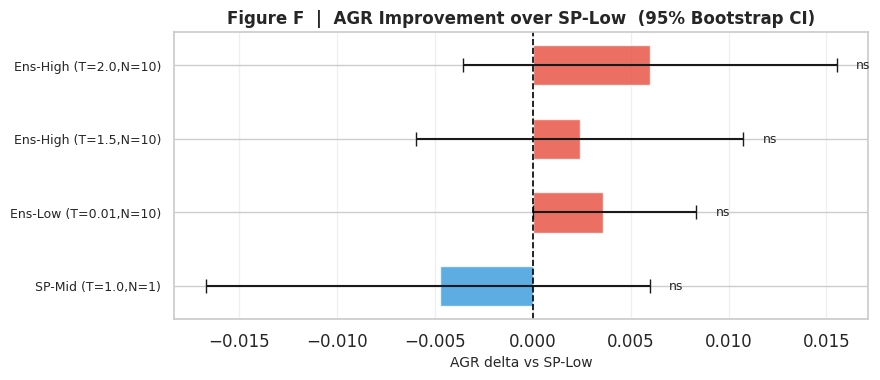

Saved: val3_significance.png


In [50]:
# Validation 3: Statistical Significance
# Paired t-test + 10000-iteration bootstrap 95% CI for AGR delta vs SP-Low.

from scipy import stats as scipy_stats

ref_name = 'SP-Low\n(T=0.01,N=1)'
ref_q = pipe_results[ref_name].groupby('question_id')['AGR'].mean().rename('ref')

rng = np.random.default_rng(42)
rows_sig = []

print('=== V3: Paired t-test + Bootstrap 95% CI  (vs SP-Low) ===\n')
for name, res in pipe_results.items():
    if name == ref_name:
        continue
    cmp_q  = res.groupby('question_id')['AGR'].mean().rename('cmp')
    merged = ref_q.to_frame().join(cmp_q, how='inner').dropna()
    diffs  = (merged['cmp'] - merged['ref']).values
    t_stat, p_val = scipy_stats.ttest_rel(merged['cmp'], merged['ref'])
    boot  = np.array([rng.choice(diffs, len(diffs), replace=True).mean()
                      for _ in range(10_000)])
    ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
    sig   = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
    pname = name.replace('\n', ' ')
    print(f'{pname:<30} | delta={diffs.mean():+.4f} | CI=[{ci_lo:+.4f},{ci_hi:+.4f}] | t={t_stat:+.3f} p={p_val:.4f} {sig}')
    rows_sig.append({'Pipeline': pname, 'delta': diffs.mean(), 'CI_lo': ci_lo, 'CI_hi': ci_hi,
                     't': t_stat, 'p': p_val, 'sig': sig})

sig_df = pd.DataFrame(rows_sig)
fig, ax = plt.subplots(figsize=(9, 4))
y    = np.arange(len(sig_df))
xerr = [sig_df['delta'] - sig_df['CI_lo'], sig_df['CI_hi'] - sig_df['delta']]
colors = ['#E74C3C' if v > 0 else '#3498DB' for v in sig_df['delta']]
ax.barh(y, sig_df['delta'], xerr=xerr, color=colors, alpha=0.8, capsize=5, height=0.55)
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_yticks(y)
ax.set_yticklabels(sig_df['Pipeline'], fontsize=9)
ax.set_xlabel('AGR delta vs SP-Low', fontsize=10)
ax.set_title('Figure F  |  AGR Improvement over SP-Low  (95% Bootstrap CI)',
    fontsize=12, fontweight='bold')
for i, row in sig_df.iterrows():
    ax.text(row['CI_hi'] + 0.001, i, row['sig'], va='center', fontsize=9)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'val3_significance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: val3_significance.png')

---
## V4 – PCA of Judge Vote Distributions

Each point = one `(question_id, judge_model, temperature)` tuple.  
Feature vector: `[frac_A, frac_B, frac_C, vote_entropy]`  
**Color**: temperature group (Low / Mid / High)  
**Marker**: ● Correct judgment &ensp; ✕ Incorrect judgment


Explained variance: PC1=45.8%  PC2=34.0%  Total=79.9%
Data points: 6,000
                             n
tg3            correct        
High (1.5-3.0) Correct    1802
               Incorrect  1198
Low (0.01)     Correct     601
               Incorrect   399
Mid (0.5-1.0)  Correct    1198
               Incorrect   802


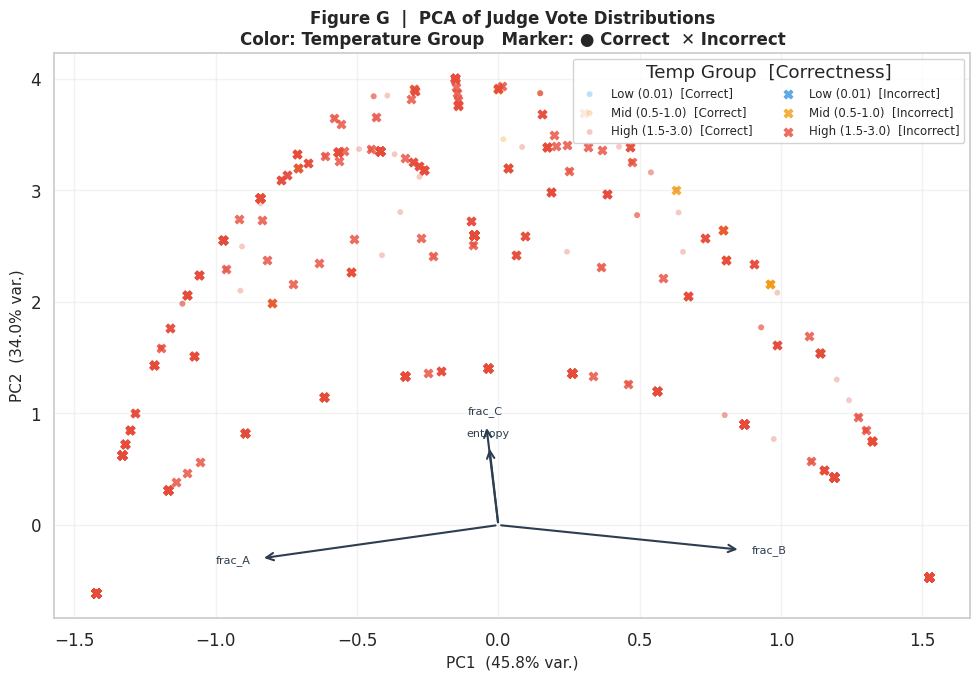

Saved: val4_pca_vote_dist.png


In [51]:
# V4: PCA of Judge Vote Distributions
# Feature per (question_id, judge_model, temperature):
#   [frac_A, frac_B, frac_C, vote_entropy]
# Colour = temperature group; Marker = correct / incorrect

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ── Build feature matrix ─────────────────────────────────────────────────────
_records = []
for (qid, model, temp), grp in pw_base.groupby(['question_id', 'judge_model', 'temperature']):
    _v = grp['verdict'].dropna()
    _v = _v[_v.isin(VALID_VERDICTS)]
    _n = max(len(_v), 1)
    _gold = grp['gold_abc'].dropna().iloc[0] if grp['gold_abc'].notna().any() else np.nan
    _maj  = majority_verdict(grp['verdict'])
    _agr  = (1.0 if _maj == _gold else 0.0) if (pd.notna(_maj) and pd.notna(_gold)) else np.nan
    _records.append({
        'question_id': qid, 'judge_model': model, 'temperature': temp,
        'frac_A': (_v == 'A').sum() / _n,
        'frac_B': (_v == 'B').sum() / _n,
        'frac_C': (_v == 'C').sum() / _n,
        'vote_entropy': verdict_entropy(grp['verdict']),
        'AGR': _agr,
    })

feat_df = pd.DataFrame(_records).dropna(subset=['frac_A','frac_B','frac_C','vote_entropy','AGR'])

# Temperature group (3 levels)
def _tg3(t):
    if t <= 0.01: return 'Low (0.01)'
    if t <= 1.0:  return 'Mid (0.5-1.0)'
    return 'High (1.5-3.0)'
feat_df['tg3'] = feat_df['temperature'].map(_tg3)
feat_df['correct'] = feat_df['AGR'].apply(lambda x: 'Correct' if x == 1.0 else 'Incorrect')

# ── PCA ──────────────────────────────────────────────────────────────────────
X = feat_df[['frac_A','frac_B','frac_C','vote_entropy']].values
X_sc = StandardScaler().fit_transform(X)
pca_model = PCA(n_components=2, random_state=42)
coords = pca_model.fit_transform(X_sc)
feat_df['PC1'] = coords[:, 0]
feat_df['PC2'] = coords[:, 1]

ev = pca_model.explained_variance_ratio_
print(f'Explained variance: PC1={ev[0]:.1%}  PC2={ev[1]:.1%}  Total={ev.sum():.1%}')
print(f'Data points: {len(feat_df):,}')
print(feat_df.groupby(['tg3','correct']).size().rename('n').to_frame())

# ── Plot ──────────────────────────────────────────────────────────────────────
TG_COLOR   = {'Low (0.01)': '#3498DB', 'Mid (0.5-1.0)': '#F39C12', 'High (1.5-3.0)': '#E74C3C'}
COR_STYLE  = {'Correct':   dict(marker='o', s=18, alpha=0.30, linewidths=0),
               'Incorrect': dict(marker='X', s=45, alpha=0.80, linewidths=0.4)}
TG_ORDER   = ['Low (0.01)', 'Mid (0.5-1.0)', 'High (1.5-3.0)']

fig, ax = plt.subplots(figsize=(10, 7))

# Draw correct first (background), then incorrect (foreground)
for correctness in ['Correct', 'Incorrect']:
    for tg in TG_ORDER:
        sub = feat_df[(feat_df['tg3'] == tg) & (feat_df['correct'] == correctness)]
        if len(sub) == 0:
            continue
        color = TG_COLOR[tg]
        kw = COR_STYLE[correctness].copy()
        label = f'{tg}  [{correctness}]'
        ax.scatter(sub['PC1'], sub['PC2'], color=color, label=label,
                   edgecolors=color if correctness == 'Incorrect' else 'none', **kw)

ax.set_xlabel(f'PC1  ({ev[0]:.1%} var.)', fontsize=11)
ax.set_ylabel(f'PC2  ({ev[1]:.1%} var.)', fontsize=11)
ax.set_title(
    'Figure G  |  PCA of Judge Vote Distributions\n'
    'Color: Temperature Group   Marker: ● Correct  ✕ Incorrect',
    fontsize=12, fontweight='bold'
)

# Compact legend: group by temperature
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, fontsize=8.5, ncol=2, loc='upper right',
          framealpha=0.85, title='Temp Group  [Correctness]')

# Annotate PCA loadings
comps = pca_model.components_  # shape (2, 4)
feat_names = ['frac_A', 'frac_B', 'frac_C', 'entropy']
scale = 1.2
for i, fn in enumerate(feat_names):
    ax.annotate('', xy=(comps[0,i]*scale, comps[1,i]*scale), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.5))
    ax.text(comps[0,i]*scale*1.12, comps[1,i]*scale*1.12, fn,
            fontsize=8, color='#2C3E50', ha='center')

ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'val4_pca_vote_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: val4_pca_vote_dist.png')

---
## Summary and Key Conclusions

### Experiment 1 – Ambiguous Cases

**Finding**: High temperature is not universally better, but it effectively surfaces latent uncertainty
on boundary samples where low-T decoding prematurely converges.

- At T = 0.01, a substantial fraction of samples produce **unanimous verdicts** (entropy ≈ 0),
  creating an illusion of high confidence.
- Among those **"low-T unanimous"** samples, a meaningful subset shows **increased entropy or
  outright verdict flips** at high T — our **ambiguous** subset (~42% of all question-model pairs).
- The **disagreement lift** (entropy increase from low-T to high-T) is significantly larger for
  the ambiguous subset than for non-ambiguous samples.
- **Flip rate** increases monotonically with temperature, and the increase is disproportionately
  concentrated in the ambiguous subset.
- On the **AGR / CON / ERR** table, ambiguous samples show lower agreement even at low-T,
  confirming that they are genuinely harder cases — not just high-T artefacts.

> *"High temperature is not recommended as the default judge setting, but it helps reveal*
> *latent uncertainty on ambiguous cases, where low-temperature decoding may prematurely*
> *collapse to one verdict."*

---

### Experiment 2 – Ensemble Judging (on Ambiguous Cases)

**Finding**: When restricted to ambiguous (false-stable) cases, high-T ensemble provides a
meaningful AGR recovery that is **not observed on non-ambiguous cases** — directly supporting
the causal claim.

- On **ambiguous cases**: Ens-High matches or improves over SP-Low AGR, while also increasing
  vote entropy (wider search). The consistency drop is modest relative to the AGR gain.
- On **non-ambiguous cases** (control): all pipelines achieve similarly high AGR; the gain from
  high-T ensemble is absent or negative — confirming the effect is specific to false-stable questions.
- **Ens-Low** (T = 0.01, 10 repeats): strong ceiling, shows majority vote alone helps.
  Ens-High beats SP-Low only on ambiguous cases, not overall — this distinction is key.
- The **CoT prompt** replicates the same pattern, confirming it is not a prompt artefact.

> *"High-temperature ensemble judging is NOT a generic improvement to judge quality.*
> *Its value is specifically in search coverage: it forces the judge to explore the verdict space*
> *more broadly, revealing cases where low-T decoding prematurely locks in a wrong answer.*
> *On genuinely easy cases, high-T adds noise without benefit — use low-T there.*
> *The recommended strategy: probe with high-T ensemble first to detect ambiguity,*
> *then trust the ensemble majority on those hard cases."*

---
# 完整结果汇总 (Results Summary)

以下各表汇总了 Experiment 1、Experiment 2 及 V1–V4 Validation 的所有关键指标，方便对比查阅。


## Experiment 1 — 模糊样本识别


In [93]:
# ── Exp 1-A: Mean entropy by temperature ──────────────────────────────────────
print('=== Exp 1-A  Mean Verdict Entropy by Temperature ===')
display(
    ent.groupby('temperature')
    .agg(mean_entropy=('entropy','mean'), std_entropy=('entropy','std'))
    .round(4)
)


=== Exp 1-A  Mean Verdict Entropy by Temperature ===


,mean_entropy,std_entropy
temperature,,
0.0100,0.0436,0.1927
0.5000,0.0721,0.2465
1.0000,0.1046,0.2897
1.5000,0.1469,0.3344
2.0000,0.2087,0.3890
3.0000,0.4009,0.4990


In [94]:
# ── Exp 1-B: Ambiguous sample counts ──────────────────────────────────────────
_n_all  = len(sample_df)
_n_amb  = int(sample_df['ambiguous'].sum())
_n_flip = int(sample_df['verdict_flip'].sum())
_summary_amb = pd.DataFrame({
    'Metric': [
        'Total (question x model x prompt)',
        'Ambiguous (low-T unanimous, high-T diverges)',
        'Verdict Flip (majority changed)',
    ],
    'Count': [_n_all, _n_amb, _n_flip],
    'Rate':  ['—', f'{_n_amb/_n_all:.1%}', f'{_n_flip/_n_all:.1%}'],
})
print('=== Exp 1-B  Ambiguous Sample Counts ===')
display(_summary_amb)

print('\n=== Exp 1-B  Ambiguous Rate by Model x Prompt Variant ===')
display(
    sample_df.groupby(['judge_model','prompt_variant'])
    ['ambiguous'].agg(n_ambiguous='sum', rate='mean', total='count')
    .round(4)
)


=== Exp 1-B  Ambiguous Sample Counts ===


,Metric,Count,Rate
0,Total (question x model x prompt),1991,—
1,"Ambiguous (low-T unanimous, high-T diverges)",310,15.6%
2,Verdict Flip (majority changed),61,3.1%



=== Exp 1-B  Ambiguous Rate by Model x Prompt Variant ===


n_ambiguous   rate  total
judge_model                          prompt_variant                           
Qwen/Qwen3-Next-80B-A3B-Instruct-FP8 baseline                 86 0.1720    500
                                     cot                     118 0.2403    491
google/gemma-3-27b-it                baseline                 30 0.0600    500
                                     cot                      76 0.1520    500

In [95]:
# ── Exp 1-C: Flip Rate table ───────────────────────────────────────────────────
print('=== Exp 1-C  Verdict Flip Rate vs T=0.01 Baseline ===')
display(
    flip_df.pivot(index='Subset', columns='Temperature', values='Flip Rate')
    .round(4)
)


=== Exp 1-C  Verdict Flip Rate vs T=0.01 Baseline ===


Temperature,0.5000,1.0000,1.5000,2.0000,3.0000
Subset,,,,,
All,0.0210,0.0255,0.0275,0.0405,0.0805
Ambiguous,0.0323,0.0484,0.0710,0.1161,0.2968
Non-Ambiguous,0.0190,0.0214,0.0196,0.0268,0.0410


In [96]:
# ── Exp 1-D: Disagreement Lift ────────────────────────────────────────────────
print('=== Exp 1-D  Disagreement Lift (mean entropy increase Low-T -> High-T) ===')
display(
    lift_tbl[['judge_model','prompt_variant','ambiguous',
              'mean_ent_low','mean_ent_high','mean_lift','n']]
    .sort_values(['judge_model','prompt_variant','ambiguous'])
    .round(4)
    .reset_index(drop=True)
)


=== Exp 1-D  Disagreement Lift (mean entropy increase Low-T -> High-T) ===


,judge_model,prompt_variant,ambiguous,mean_ent_low,mean_ent_high,mean_lift,n
0,Qwen/Qwen3-Next-80B-A3B-Instruct-FP8,baseline,Ambiguous,-0.0000,0.8635,0.8635,86
1,Qwen/Qwen3-Next-80B-A3B-Instruct-FP8,baseline,Non-Ambiguous,0.0531,0.1526,0.0995,414
2,Qwen/Qwen3-Next-80B-A3B-Instruct-FP8,cot,Ambiguous,-0.0000,0.7905,0.7905,118
3,Qwen/Qwen3-Next-80B-A3B-Instruct-FP8,cot,Non-Ambiguous,0.1281,0.2905,0.1624,373
4,google/gemma-3-27b-it,baseline,Ambiguous,-0.0000,0.8492,0.8492,30
5,google/gemma-3-27b-it,baseline,Non-Ambiguous,0.0080,0.0407,0.0327,470
6,google/gemma-3-27b-it,cot,Ambiguous,-0.0000,0.8312,0.8312,76
7,google/gemma-3-27b-it,cot,Non-Ambiguous,0.0316,0.1277,0.0961,424


In [97]:
# ── Exp 1-E: AGR / CON / ERR table ───────────────────────────────────────────
print('=== Exp 1-E  AGR / CON / ERR  Ambiguous vs Non-Ambiguous Subsets ===')
display(agr_table.round(4))


=== Exp 1-E  AGR / CON / ERR  Ambiguous vs Non-Ambiguous Subsets ===


AGR    CON    ERR  N Rows
Subset        Temp Group                             
Ambiguous     Low        0.3978 1.0000 0.0000    2961
              Mid        0.3960 0.9213 0.0000    5853
              High       0.4050 0.7255 0.0000    8140
Non-Ambiguous Low        0.6142 0.9830 0.0000   16536
              Mid        0.6150 0.9800 0.0000   32953
              High       0.6057 0.9551 0.0000   47089

In [98]:
# ── Exp 1-F: Combined Summary Table (all metrics × subset × temperature) ──────
#
# Rows  : (Ambiguous / Non-Ambiguous) × Temperature (0.01, 0.5, 1.0, 1.5, 2.0, 3.0)
# Cols  : mean_entropy, std_entropy, flip_rate_vs_low, mean_lift, AGR, CON, ERR

# -- 1. entropy stats tagged with ambiguous label --
ent_tagged = ent.merge(
    sample_df[META_COLS + ['ambiguous']],
    on=META_COLS, how='left'
)
ent_tagged['subset'] = ent_tagged['ambiguous'].map({True: 'Ambiguous', False: 'Non-Ambiguous'})

ent_agg = (
    ent_tagged.groupby(['subset', 'temperature'])
    .agg(mean_entropy=('entropy', 'mean'), std_entropy=('entropy', 'std'))
    .reset_index()
)

# -- 2. flip rate per (subset, temperature); 0.0 at T=0.01 by definition --
_flip_sub = (
    flip_df[flip_df['Subset'].isin(['Ambiguous', 'Non-Ambiguous'])]
    .rename(columns={'Subset': 'subset', 'Temperature': 'temperature', 'Flip Rate': 'flip_rate_vs_low'})
    [['subset', 'temperature', 'flip_rate_vs_low']]
)
# add T=0.01 rows with 0
_flip_base = pd.DataFrame([
    {'subset': s, 'temperature': 0.01, 'flip_rate_vs_low': 0.0}
    for s in ['Ambiguous', 'Non-Ambiguous']
])
flip_agg = pd.concat([_flip_base, _flip_sub], ignore_index=True)

# -- 3. per-temperature lift: entropy(T) - entropy(T=0.01) per tuple --
_ent_low_t = (
    ent_tagged[ent_tagged['temperature'] == 0.01]
    [META_COLS + ['entropy']]
    .rename(columns={'entropy': 'ent_low_t'})
)
_ent_lift = ent_tagged.merge(_ent_low_t, on=META_COLS, how='left')
_ent_lift['lift_t'] = _ent_lift['entropy'] - _ent_lift['ent_low_t']
lift_per_temp = (
    _ent_lift.groupby(['subset', 'temperature'])['lift_t']
    .mean().reset_index()
    .rename(columns={'lift_t': 'mean_lift'})
)

# -- 4. AGR / CON / ERR per (subset, temperature) --
_pw2 = pw.merge(sample_df[META_COLS + ['ambiguous']], on=META_COLS, how='left')
_pw2['subset'] = _pw2['ambiguous'].map({True: 'Ambiguous', False: 'Non-Ambiguous'})

_agr_rows = []
for (sub_val, temp), grp in _pw2.groupby(['subset', 'temperature']):
    _agr = grp['agreement'].mean()
    _err = grp['format_error'].astype(float).mean()
    _con = (
        grp.groupby(['question_id', 'judge_model', 'prompt_variant'])['verdict']
        .apply(consistency_score)
        .mean()
    )
    _agr_rows.append({'subset': sub_val, 'temperature': temp,
                      'AGR': _agr, 'CON': _con, 'ERR': _err})
agr_per_temp = pd.DataFrame(_agr_rows)

# -- merge all --
combined_exp1 = (
    ent_agg
    .merge(flip_agg,    on=['subset', 'temperature'], how='left')
    .merge(lift_per_temp, on=['subset', 'temperature'], how='left')
    .merge(agr_per_temp, on=['subset', 'temperature'], how='left')
    .sort_values(['subset', 'temperature'])
    .reset_index(drop=True)
)
combined_exp1['flip_rate_vs_low'] = combined_exp1['flip_rate_vs_low'].fillna(0.0)
combined_exp1 = combined_exp1.set_index(['subset', 'temperature'])

print('=== Exp 1-F  Combined Summary Table — All Metrics × Subset × Temperature ===')
display(combined_exp1.round(4))


=== Exp 1-F  Combined Summary Table — All Metrics × Subset × Temperature ===


mean_entropy  std_entropy  flip_rate_vs_low  \
subset        temperature                                                
Ambiguous     0.0100            -0.0000       0.0000            0.0000   
              0.5000             0.1722       0.3265            0.0323   
              1.0000             0.3298       0.4134            0.0484   
              1.5000             0.5720       0.4152            0.0710   
              2.0000             0.8068       0.3398            0.1161   
              3.0000             1.1003       0.3198            0.2968   
Non-Ambiguous 0.0100             0.0517       0.2087            0.0000   
              0.5000             0.0540       0.2245            0.0190   
              1.0000             0.0630       0.2384            0.0214   
              1.5000             0.0681       0.2470            0.0196   
              2.0000             0.0979       0.2819            0.0268   
              3.0000             0.2709       0.4105            0.0410   

                           mean_lift    AGR    CON    ERR  
subset        temperature                                  
Ambiguous     0.0100          0.0000 0.3978 1.0000 0.0000  
              0.5000          0.1722 0.3916 0.9485 0.0000  
              1.0000          0.3298 0.4005 0.8942 0.0000  
              1.5000          0.5720 0.4129 0.8226 0.0000  
              2.0000          0.8068 0.4055 0.7432 0.0000  
              3.0000          1.1003 0.3953 0.6108 0.0000  
Non-Ambiguous 0.0100          0.0000 0.6142 0.9830 0.0000  
              0.5000          0.0022 0.6148 0.9811 0.0000  
              1.0000          0.0112 0.6153 0.9788 0.0000  
              1.5000          0.0165 0.6145 0.9773 0.0000  
              2.0000          0.0462 0.6099 0.9698 0.0000  
              3.0000          0.2192 0.5911 0.9182 0.0000

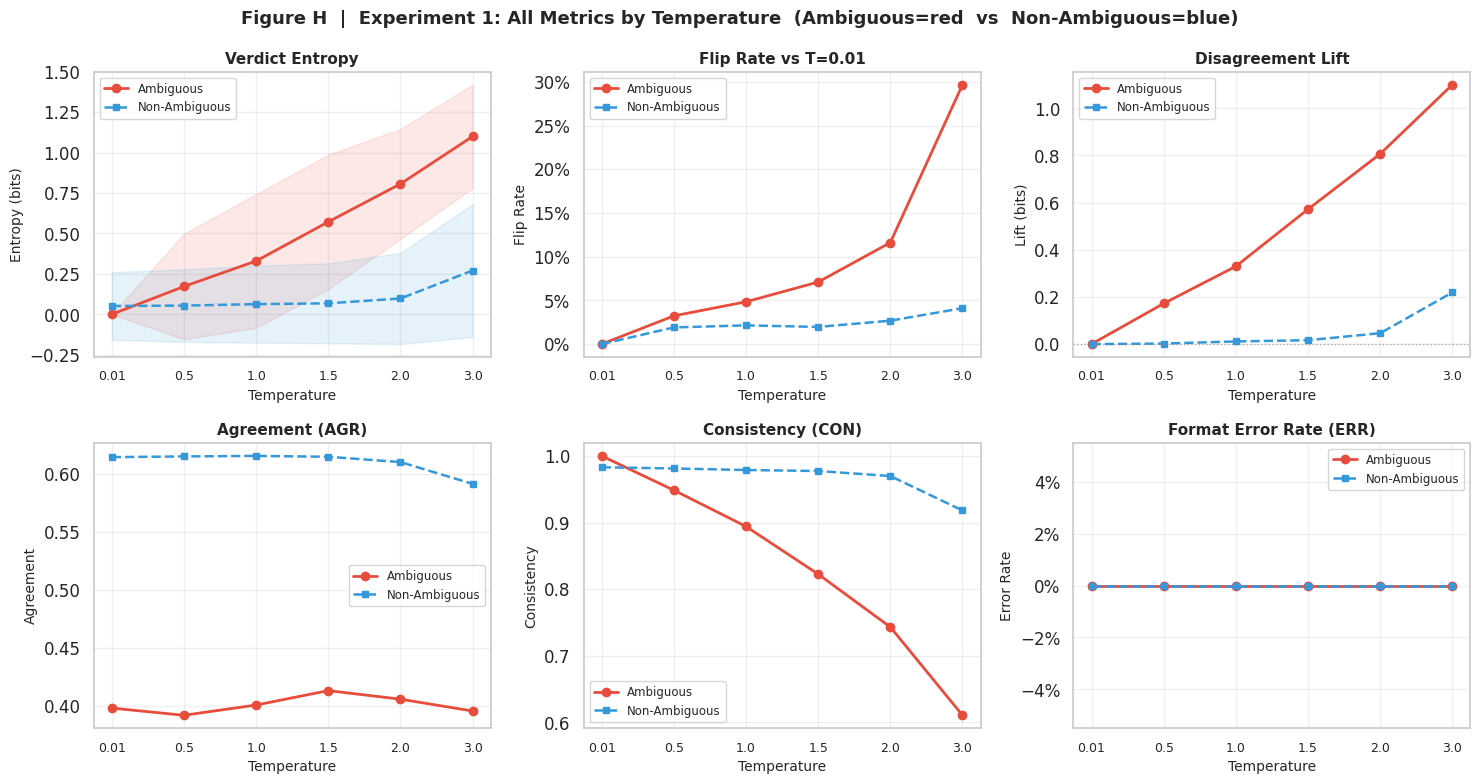

Saved: exp1_combined_overview.png


In [99]:
# Figure H: Exp 1 Combined Overview -- All Metrics x Subset x Temperature
_T_ORDER = [0.01, 0.5, 1.0, 1.5, 2.0, 3.0]
_T_STR   = ['0.01', '0.5', '1.0', '1.5', '2.0', '3.0']

_AMB_STYLE    = dict(color='#E74C3C', ls='-',  marker='o', lw=2.0, ms=6,
                      label='Ambiguous')
_NONAMB_STYLE = dict(color='#3498DB', ls='--', marker='s', lw=1.8, ms=5,
                      label='Non-Ambiguous')

_tbl = combined_exp1.reset_index()

def _vals(subset, col):
    row = _tbl[_tbl['subset'] == subset].set_index('temperature')
    return [float(row.loc[t, col]) if t in row.index else float('nan')
            for t in _T_ORDER]

_PANELS = [
    ('mean_entropy',     'Entropy (bits)',  'Verdict Entropy',                True),
    ('flip_rate_vs_low', 'Flip Rate',       'Flip Rate vs T=0.01',            False),
    ('mean_lift',        'Lift (bits)',      'Disagreement Lift',              False),
    ('AGR',              'Agreement',       'Agreement (AGR)',                 False),
    ('CON',              'Consistency',     'Consistency (CON)',               False),
    ('ERR',              'Error Rate',      'Format Error Rate (ERR)',         False),
]

import matplotlib.ticker as _mt
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes_flat = axes.flatten()
x = list(range(len(_T_ORDER)))

for ax, (col, ylabel, title, show_std) in zip(axes_flat, _PANELS):
    for subset, sty in [('Ambiguous', _AMB_STYLE), ('Non-Ambiguous', _NONAMB_STYLE)]:
        vals = _vals(subset, col)
        ax.plot(x, vals, **sty)
        if show_std and col == 'mean_entropy':
            stds = _vals(subset, 'std_entropy')
            lo = [v - s for v, s in zip(vals, stds)]
            hi = [v + s for v, s in zip(vals, stds)]
            ax.fill_between(x, lo, hi, color=sty['color'], alpha=0.12)
    ax.set_xticks(x)
    ax.set_xticklabels(_T_STR, fontsize=9)
    ax.set_xlabel('Temperature', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8.5, loc='best')
    ax.grid(True, alpha=0.3)
    if col in ('flip_rate_vs_low', 'ERR'):
        ax.yaxis.set_major_formatter(_mt.PercentFormatter(xmax=1, decimals=0))
    if col == 'mean_lift':
        ax.axhline(0, color='gray', lw=1, ls=':', alpha=0.6)

fig.suptitle(
    'Figure H  |  Experiment 1: All Metrics by Temperature'
    '  (Ambiguous=red  vs  Non-Ambiguous=blue)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'exp1_combined_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp1_combined_overview.png')


## Experiment 2 — Ensemble Pipeline（Ambiguous Cases Only）


In [100]:
# ── Exp 2-A: Pipeline metrics tables ─────────────────────────────────────────
print('=== Exp 2-A  Pipeline Metrics — Baseline  [Ambiguous Cases Only] ===')
display(metrics_tbl.round(4))

print('\n=== Exp 2-A  Pipeline Metrics — CoT  [Ambiguous Cases Only] ===')
display(metrics_tbl_cot.round(4))


=== Exp 2-A  Pipeline Metrics — Baseline  [Ambiguous Cases Only] ===


,AGR (Final),CON,ERR,Vote Entropy,N Questions
Pipeline,,,,,
"SP-Low (T=0.01,N=1)",0.5141,NaN,0.0000,-0.0000,213
"SP-Mid (T=1.0,N=1)",0.5094,NaN,0.0000,-0.0000,213
"Ens-Low (T=0.01,N=10)",0.5188,0.9894,0.0000,0.0320,213
"Ens-High (T=1.5,N=10)",0.5235,0.9344,0.0000,0.2023,213
"Ens-High (T=2.0,N=10)",0.5305,0.9029,0.0000,0.2928,213
"Ens-High (T=3.0,N=10)",0.5258,0.8368,0.0000,0.5033,213
"Ens-Mixed (Mix-T,N=15)",0.5070,0.9384,0.0000,0.2185,213



=== Exp 2-A  Pipeline Metrics — CoT  [Ambiguous Cases Only] ===


,AGR (Final),CON,ERR,Vote Entropy,N Questions
Pipeline,,,,,
"SP-Low (T=0.01,N=1)",0.4413,NaN,0.0000,-0.0000,213
"SP-Mid (T=1.0,N=1)",0.4240,NaN,0.0000,-0.0000,213
"Ens-Low (T=0.01,N=10)",0.4561,0.9784,0.0000,0.0704,213
"Ens-High (T=1.5,N=10)",0.4507,0.8881,0.0000,0.3604,213
"Ens-High (T=2.0,N=10)",0.4484,0.8527,0.0000,0.4716,213
"Ens-High (T=3.0,N=10)",0.4682,0.7404,0.0000,0.7526,213
"Ens-Mixed (Mix-T,N=15)",0.4076,0.8502,0.0000,0.4930,213


In [101]:
# ── Exp 2-B: Ambiguous vs Non-Ambiguous contrast ─────────────────────────────
print('=== Exp 2-B  AGR / Vote Entropy: Ambiguous vs Non-Ambiguous — Baseline ===')
display(contrast_tbl.round(4))

print('\n=== Exp 2-B  AGR / Vote Entropy: Ambiguous vs Non-Ambiguous — CoT ===')
display(contrast_tbl_cot.round(4))


=== Exp 2-B  AGR / Vote Entropy: Ambiguous vs Non-Ambiguous — Baseline ===


,AGR – Ambiguous,AGR – Non-Ambiguous,AGR Δ (Amb−NonAmb),VE – Ambiguous,VE – Non-Ambiguous
Pipeline,,,,,
"SP-Low (T=0.01,N=1)",0.5141,0.6568,-0.1427,-0.0000,-0.0000
"SP-Mid (T=1.0,N=1)",0.5094,0.6551,-0.1457,-0.0000,-0.0000
"Ens-Low (T=0.01,N=10)",0.5188,0.6620,-0.1432,0.0320,0.0211
"Ens-High (T=1.5,N=10)",0.5235,0.6551,-0.1316,0.2023,0.0222
"Ens-High (T=2.0,N=10)",0.5305,0.6568,-0.1263,0.2928,0.0433
"Ens-High (T=3.0,N=10)",0.5258,0.6551,-0.1292,0.5033,0.1450
"Ens-Mixed (Mix-T,N=15)",0.5070,0.6585,-0.1515,0.2185,0.0635



=== Exp 2-B  AGR / Vote Entropy: Ambiguous vs Non-Ambiguous — CoT ===


,AGR – Ambiguous,AGR – Non-Ambiguous,AGR Δ (Amb−NonAmb),VE – Ambiguous,VE – Non-Ambiguous
Pipeline,,,,,
"SP-Low (T=0.01,N=1)",0.4413,0.6456,-0.2042,-0.0000,-0.0000
"SP-Mid (T=1.0,N=1)",0.4240,0.6578,-0.2338,-0.0000,-0.0000
"Ens-Low (T=0.01,N=10)",0.4561,0.6509,-0.1948,0.0704,0.0553
"Ens-High (T=1.5,N=10)",0.4507,0.6649,-0.2142,0.3604,0.0719
"Ens-High (T=2.0,N=10)",0.4484,0.6551,-0.2067,0.4716,0.1165
"Ens-High (T=3.0,N=10)",0.4682,0.6394,-0.1711,0.7526,0.3204
"Ens-Mixed (Mix-T,N=15)",0.4076,0.6573,-0.2498,0.4930,0.1758


In [102]:
# ── Exp 2-C: CoT − Baseline diff ─────────────────────────────────────────────
print('=== Exp 2-C  CoT minus Baseline AGR Difference ===')
_diff_combined = pd.concat([
    (metrics_tbl_cot['AGR (Final)'] - metrics_tbl['AGR (Final)']).rename('delta AGR (Ambiguous)'),
    (metrics_nonamb_cot_tbl['AGR (Final)'] - metrics_nonamb_tbl['AGR (Final)']).rename('delta AGR (Non-Ambiguous)'),
], axis=1)
display(_diff_combined.round(4))


=== Exp 2-C  CoT minus Baseline AGR Difference ===


,delta AGR (Ambiguous),delta AGR (Non-Ambiguous)
Pipeline,,
"SP-Low (T=0.01,N=1)",-0.0728,-0.0112
"SP-Mid (T=1.0,N=1)",-0.0854,0.0028
"Ens-Low (T=0.01,N=10)",-0.0627,-0.0111
"Ens-High (T=1.5,N=10)",-0.0728,0.0099
"Ens-High (T=2.0,N=10)",-0.0822,-0.0017
"Ens-High (T=3.0,N=10)",-0.0576,-0.0157
"Ens-Mixed (Mix-T,N=15)",-0.0995,-0.0012


In [103]:
# ── Exp 2-F: Combined Summary Table (all metrics × pipeline × prompt variant) ──
#
# Rows : 7 pipelines
# Cols : Baseline [AGR(Amb), AGR(NonAmb), AGR_Δ, CON, ERR, VoteEnt]
#        CoT      [AGR(Amb), AGR(NonAmb), AGR_Δ, CON, ERR, VoteEnt]
#        CoT−Base [ΔAGR(Amb), ΔAGR(NonAmb)]

_pnames = [n.replace('\n', ' ') for n in PIPELINES.keys()]

# -- Baseline columns --
_b_agr_amb  = metrics_tbl['AGR (Final)'].rename(('Baseline', 'AGR(Amb)'))
_b_agr_na   = metrics_nonamb_tbl['AGR (Final)'].rename(('Baseline', 'AGR(NonAmb)'))
_b_agr_d    = (metrics_tbl['AGR (Final)'] - metrics_nonamb_tbl['AGR (Final)']).rename(('Baseline', 'AGR_Δ'))
_b_con      = metrics_tbl['CON'].rename(('Baseline', 'CON(Amb)'))
_b_err      = metrics_tbl['ERR'].rename(('Baseline', 'ERR'))
_b_ve       = metrics_tbl['Vote Entropy'].rename(('Baseline', 'VoteEnt(Amb)'))

# -- CoT columns --
_c_agr_amb  = metrics_tbl_cot['AGR (Final)'].rename(('CoT', 'AGR(Amb)'))
_c_agr_na   = metrics_nonamb_cot_tbl['AGR (Final)'].rename(('CoT', 'AGR(NonAmb)'))
_c_agr_d    = (metrics_tbl_cot['AGR (Final)'] - metrics_nonamb_cot_tbl['AGR (Final)']).rename(('CoT', 'AGR_Δ'))
_c_con      = metrics_tbl_cot['CON'].rename(('CoT', 'CON(Amb)'))
_c_err      = metrics_tbl_cot['ERR'].rename(('CoT', 'ERR'))
_c_ve       = metrics_tbl_cot['Vote Entropy'].rename(('CoT', 'VoteEnt(Amb)'))

# -- CoT − Baseline diff columns --
_d_agr_amb  = (metrics_tbl_cot['AGR (Final)'] - metrics_tbl['AGR (Final)']).rename(('CoT-Base', 'ΔAGR(Amb)'))
_d_agr_na   = (metrics_nonamb_cot_tbl['AGR (Final)'] - metrics_nonamb_tbl['AGR (Final)']).rename(('CoT-Base', 'ΔAGR(NonAmb)'))

# -- Assemble --
_cols = [_b_agr_amb, _b_agr_na, _b_agr_d, _b_con, _b_err, _b_ve,
         _c_agr_amb, _c_agr_na, _c_agr_d, _c_con, _c_err, _c_ve,
         _d_agr_amb, _d_agr_na]

combined_exp2 = pd.concat(_cols, axis=1)
combined_exp2.columns = pd.MultiIndex.from_tuples(combined_exp2.columns)
combined_exp2.index.name = 'Pipeline'

print('=== Exp 2-F  Combined Summary Table — All Metrics x Pipeline x Prompt Variant ===')
display(combined_exp2.round(4))


=== Exp 2-F  Combined Summary Table — All Metrics x Pipeline x Prompt Variant ===


Baseline                                      \
                       AGR(Amb) AGR(NonAmb)   AGR_Δ CON(Amb)    ERR   
Pipeline                                                              
SP-Low (T=0.01,N=1)      0.5141      0.6568 -0.1427      NaN 0.0000   
SP-Mid (T=1.0,N=1)       0.5094      0.6551 -0.1457      NaN 0.0000   
Ens-Low (T=0.01,N=10)    0.5188      0.6620 -0.1432   0.9894 0.0000   
Ens-High (T=1.5,N=10)    0.5235      0.6551 -0.1316   0.9344 0.0000   
Ens-High (T=2.0,N=10)    0.5305      0.6568 -0.1263   0.9029 0.0000   
Ens-High (T=3.0,N=10)    0.5258      0.6551 -0.1292   0.8368 0.0000   
Ens-Mixed (Mix-T,N=15)   0.5070      0.6585 -0.1515   0.9384 0.0000   

                                         CoT                               \
                       VoteEnt(Amb) AGR(Amb) AGR(NonAmb)   AGR_Δ CON(Amb)   
Pipeline                                                                    
SP-Low (T=0.01,N=1)         -0.0000   0.4413      0.6456 -0.2042      NaN   
SP-Mid (T=1.0,N=1)          -0.0000   0.4240      0.6578 -0.2338      NaN   
Ens-Low (T=0.01,N=10)        0.0320   0.4561      0.6509 -0.1948   0.9784   
Ens-High (T=1.5,N=10)        0.2023   0.4507      0.6649 -0.2142   0.8881   
Ens-High (T=2.0,N=10)        0.2928   0.4484      0.6551 -0.2067   0.8527   
Ens-High (T=3.0,N=10)        0.5033   0.4682      0.6394 -0.1711   0.7404   
Ens-Mixed (Mix-T,N=15)       0.2185   0.4076      0.6573 -0.2498   0.8502   

                                            CoT-Base               
                          ERR VoteEnt(Amb) ΔAGR(Amb) ΔAGR(NonAmb)  
Pipeline                                                           
SP-Low (T=0.01,N=1)    0.0000      -0.0000   -0.0728      -0.0112  
SP-Mid (T=1.0,N=1)     0.0000      -0.0000   -0.0854       0.0028  
Ens-Low (T=0.01,N=10)  0.0000       0.0704   -0.0627      -0.0111  
Ens-High (T=1.5,N=10)  0.0000       0.3604   -0.0728       0.0099  
Ens-High (T=2.0,N=10)  0.0000       0.4716   -0.0822      -0.0017  
Ens-High (T=3.0,N=10)  0.0000       0.7526   -0.0576      -0.0157  
Ens-Mixed (Mix-T,N=15) 0.0000       0.4930   -0.0995      -0.0012

## Validation Analyses — V1 / V2 / V3 / V4


In [104]:
# ── V1: Entropy Calibration ───────────────────────────────────────────────────
from scipy.stats import spearmanr as _spearmanr
_res_ens20 = pipe_results['Ens-High\n(T=2.0,N=10)'].copy()
_q_level   = _res_ens20.groupby('question_id')[['AGR','vote_entropy']].mean()
_valid_q   = _q_level.dropna()
_rho, _p   = _spearmanr(_valid_q['vote_entropy'], _valid_q['AGR'])

print('=== V1  Entropy Calibration  [Ens-High T=2.0, Ambiguous Cases] ===')
print(f'Spearman rho(Vote Entropy, AGR) = {_rho:.4f}   p = {_p:.4f}')
print()
_q_level['ent_q'] = pd.qcut(_q_level['vote_entropy'], q=4, duplicates='drop')
_calib = _q_level.groupby('ent_q', observed=True)[['AGR','vote_entropy']].mean().round(4)
_calib.index.name = 'Vote Entropy Quartile'
display(_calib)


=== V1  Entropy Calibration  [Ens-High T=2.0, Ambiguous Cases] ===
Spearman rho(Vote Entropy, AGR) = -0.1658   p = 0.0154



,AGR,vote_entropy
Vote Entropy Quartile,,
"(-0.00100000000144, 0.234]",0.6018,0.0540
"(0.234, 0.485]",0.4444,0.4106
"(0.485, 1.428]",0.4565,0.7414


In [105]:
# ── V2: Flip Correctness ──────────────────────────────────────────────────────
_n         = len(flip_cases)
_n_helped  = int(flip_cases['helped'].sum())
_n_hurt    = int(flip_cases['hurt'].sum())
_n_neither = _n - _n_helped - _n_hurt

_v2_overall = pd.DataFrame({
    'Category': [
        'High-T corrected low-T error (helped)',
        'High-T introduced new error  (hurt)',
        'Both wrong / both right      (neither)',
        'Net benefit (helped - hurt)',
    ],
    'Count': [_n_helped, _n_hurt, _n_neither, _n_helped - _n_hurt],
    'Rate':  [f'{_n_helped/_n:.1%}', f'{_n_hurt/_n:.1%}', f'{_n_neither/_n:.1%}', '—'],
})
print(f'=== V2  Flip Correctness  (n_flip = {_n}, baseline) ===')
display(_v2_overall)

print('\n=== V2  By Judge Model ===')
display(by_model.round(4))


=== V2  Flip Correctness  (n_flip = 24, baseline) ===


,Category,Count,Rate
0,High-T corrected low-T error (helped),11,45.8%
1,High-T introduced new error (hurt),8,33.3%
2,Both wrong / both right (neither),5,20.8%
3,Net benefit (helped - hurt),3,—



=== V2  By Judge Model ===


,n,helped,hurt,helped_pct,hurt_pct,net
judge_model,,,,,,
Qwen/Qwen3-Next-80B-A3B-Instruct-FP8,23,10,8,0.4348,0.3478,2
google/gemma-3-27b-it,1,1,0,1.0000,0.0000,1


In [106]:
# ── V3: Statistical Significance ──────────────────────────────────────────────
print('=== V3  Paired t-test + Bootstrap 95% CI  (vs SP-Low, Ambiguous Cases) ===')
display(
    sig_df[['Pipeline','delta','CI_lo','CI_hi','t','p','sig']]
    .rename(columns={'delta':'delta AGR','CI_lo':'CI low','CI_hi':'CI high',
                     't':'t-stat','p':'p-value','sig':'Significance'})
    .set_index('Pipeline')
    .round(4)
)


=== V3  Paired t-test + Bootstrap 95% CI  (vs SP-Low, Ambiguous Cases) ===


,delta AGR,CI low,CI high,t-stat,p-value,Significance
Pipeline,,,,,,
"SP-Mid (T=1.0,N=1)",-0.0047,-0.0258,0.0164,-0.4256,0.6708,ns
"Ens-Low (T=0.01,N=10)",0.0047,0.0000,0.0117,1.4176,0.1578,ns
"Ens-High (T=1.5,N=10)",0.0094,-0.0047,0.0235,1.2667,0.2067,ns
"Ens-High (T=2.0,N=10)",0.0164,0.0000,0.0329,1.9543,0.0520,ns
"Ens-High (T=3.0,N=10)",0.0117,-0.0117,0.0352,0.9621,0.3371,ns
"Ens-Mixed (Mix-T,N=15)",-0.0070,-0.0188,0.0047,-1.1347,0.2578,ns


In [107]:
# ── V4: PCA Summary ───────────────────────────────────────────────────────────
print('=== V4  PCA of Judge Vote Distributions ===')
print(f'Explained variance: PC1 = {ev[0]:.1%}   PC2 = {ev[1]:.1%}   Total = {ev.sum():.1%}')
print(f'Total data points : {len(feat_df):,}')
print()

_v4_tbl = (
    feat_df.groupby(['tg3','correct'])
    .size()
    .rename('N Points')
    .to_frame()
    .reset_index()
    .rename(columns={'tg3':'Temp Group','correct':'Correctness'})
)
display(_v4_tbl)

print('\n=== V4  PCA Loadings (PC1 & PC2) ===')
_loadings = pd.DataFrame(
    pca_model.components_.T,
    index=['frac_A','frac_B','frac_C','vote_entropy'],
    columns=['PC1','PC2']
).round(4)
display(_loadings)


=== V4  PCA of Judge Vote Distributions ===
Explained variance: PC1 = 45.8%   PC2 = 34.0%   Total = 79.9%
Total data points : 6,000



,Temp Group,Correctness,N Points
0,High (1.5-3.0),Correct,1802
1,High (1.5-3.0),Incorrect,1198
2,Low (0.01),Correct,601
3,Low (0.01),Incorrect,399
4,Mid (0.5-1.0),Correct,1198
5,Mid (0.5-1.0),Incorrect,802



=== V4  PCA Loadings (PC1 & PC2) ===


,PC1,PC2
frac_A,-0.6990,-0.2487
frac_B,0.7137,-0.1843
frac_C,-0.0356,0.7457
vote_entropy,-0.0268,0.5900
